In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, StratifiedGroupKFold
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Loading Data

In [25]:
bank_data = pd.read_csv("/workspaces/Machine-Learning-for-Bank-Marketing/data/bank.csv")
bank_data.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [26]:
print(f"Columns in Bank Data: {bank_data.columns}")

Columns in Bank Data: Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'deposit'],
      dtype='object')


In [27]:
bank_data['contact'].value_counts()

contact
cellular     8042
unknown      2346
telephone     774
Name: count, dtype: int64

- **'default'**:
    - "yes" → the client has a history of default
    - "no" → the client has not defaulted
    - "unknown" → bank doesn’t have information
- **'pdays'** → Number of days since the client was last contacted in a previous campaign. This is an important feature — frequent recent contacts may influence the outcome.
- **'previous'** → Number of times the client was contacted before this campaign. 0 → no previous contacts. Higher numbers mean the client was targeted multiple times.
- **'poutcome'** → Outcome of the previous marketing campaign.

In [28]:
# Check Missing Values
print(f"Count of Misssing Values if DataSet: {bank_data.isna().sum().sum()}")

Count of Misssing Values if DataSet: 0


In [29]:
# Columns With Unknown Values and the % of total
unknown_summary = []
categorical_cols = [col for col in bank_data.columns if bank_data[col].dtype == 'object']

for col in categorical_cols:
    if 'unknown' in bank_data[col].values:
        count_unknown = (bank_data[col].str.lower() == 'unknown').sum()
        percent_unknown = (count_unknown / len(bank_data)) * 100
        unknown_summary.append({'Column': col, 
                                'Unknown Count': count_unknown, 
                                'Percentage': round(percent_unknown, 2)})

unknown_df = pd.DataFrame(unknown_summary)
print(unknown_df)

      Column  Unknown Count  Percentage
0        job             70        0.63
1  education            497        4.45
2    contact           2346       21.02
3   poutcome           8326       74.59


In [30]:
print(f"Len Before Droping Unknown:{len(bank_data)}")
# Droping Unknown value whose percentage of missing value is < 5%
cols_to_drop_unknown = unknown_df.loc[unknown_df['Percentage'] < 5, 'Column']

# Drop rows where these columns have 'unknown'
for col in cols_to_drop_unknown:
    bank_data = bank_data[bank_data[col] != 'unknown']

# Reset index after dropping rows
bank_data.reset_index(drop=True, inplace=True)

print(f"Len After Droping Unknown:{len(bank_data)}")

Len Before Droping Unknown:11162
Len After Droping Unknown:10634


In [31]:
# Imputation for Contact with the most frequent contact type
most_freq_contact = bank_data['contact'].mode()[0]
print("Most frequent contact type:", most_freq_contact)

# Replace unknowns with the most frequent
bank_data['contact'] = bank_data['contact'].str.lower().replace('unknown', most_freq_contact)


Most frequent contact type: cellular


# Analysing Categorical Colums

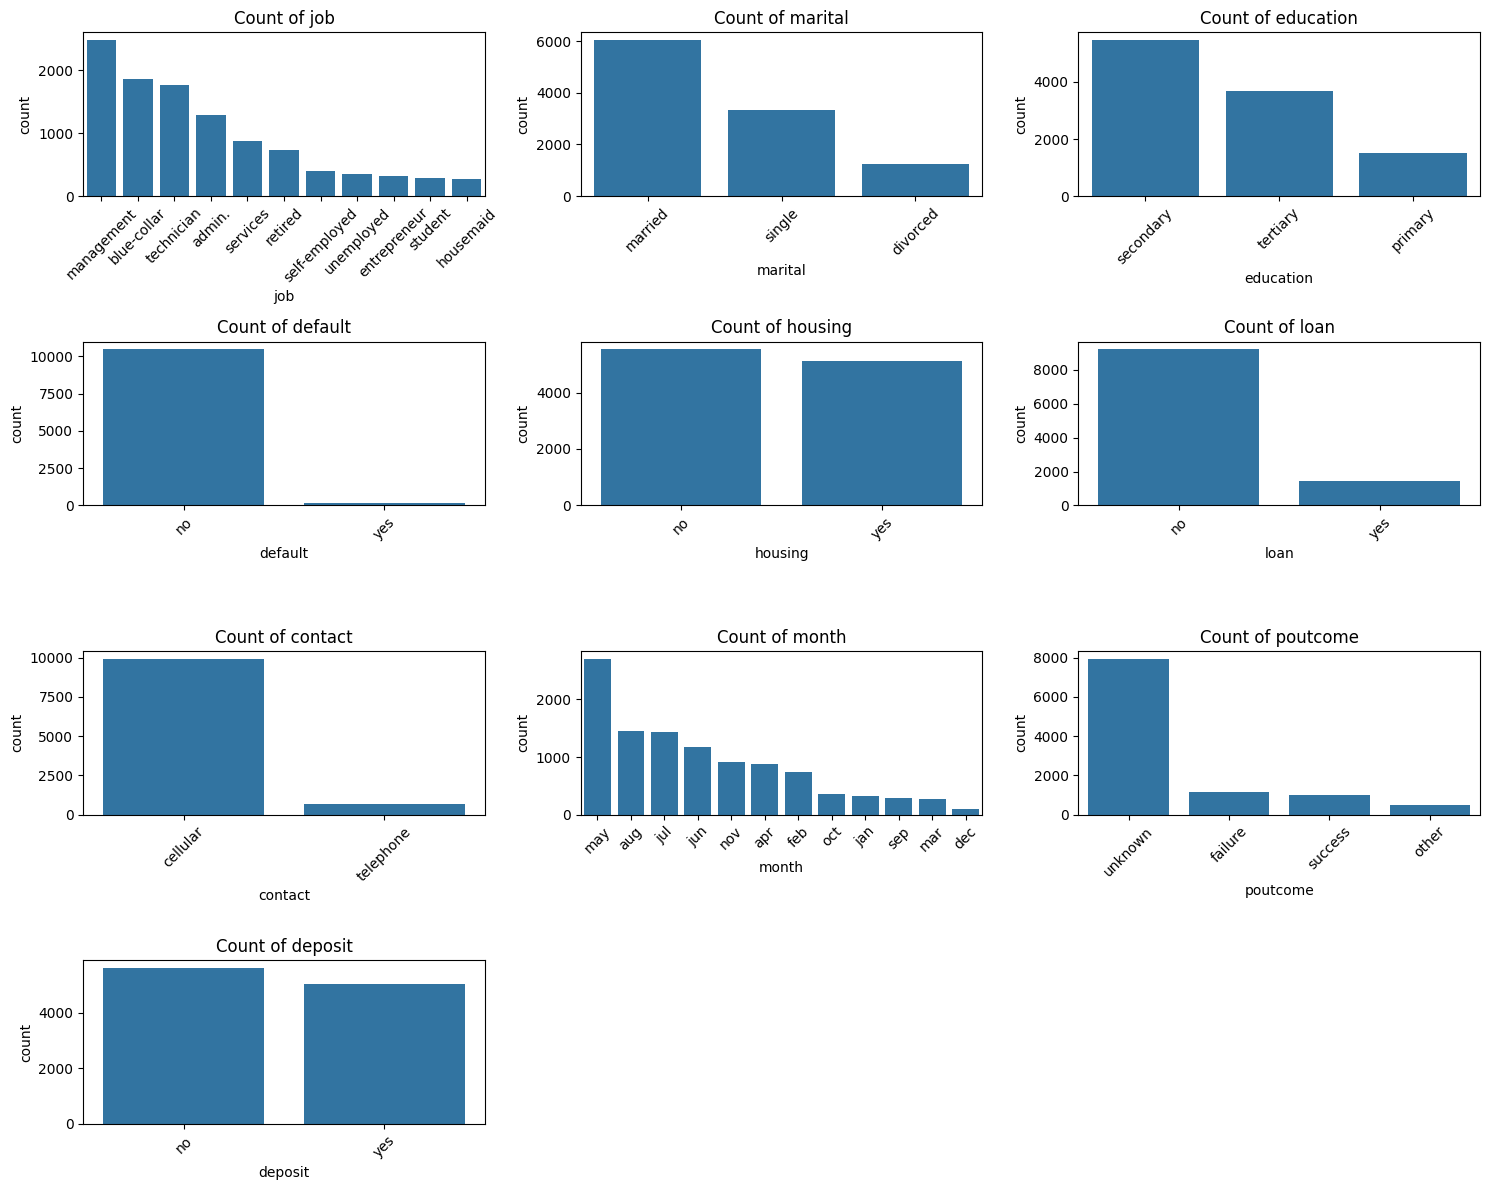

In [32]:
plt.figure(figsize=(15,12))

for i, col in enumerate(categorical_cols, 1):
    plt.subplot(4, 3, i)
    sns.countplot(x=col, data=bank_data, order=bank_data[col].value_counts().index)
    plt.title(f"Count of {col}")
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Analysis of Numrical Columns

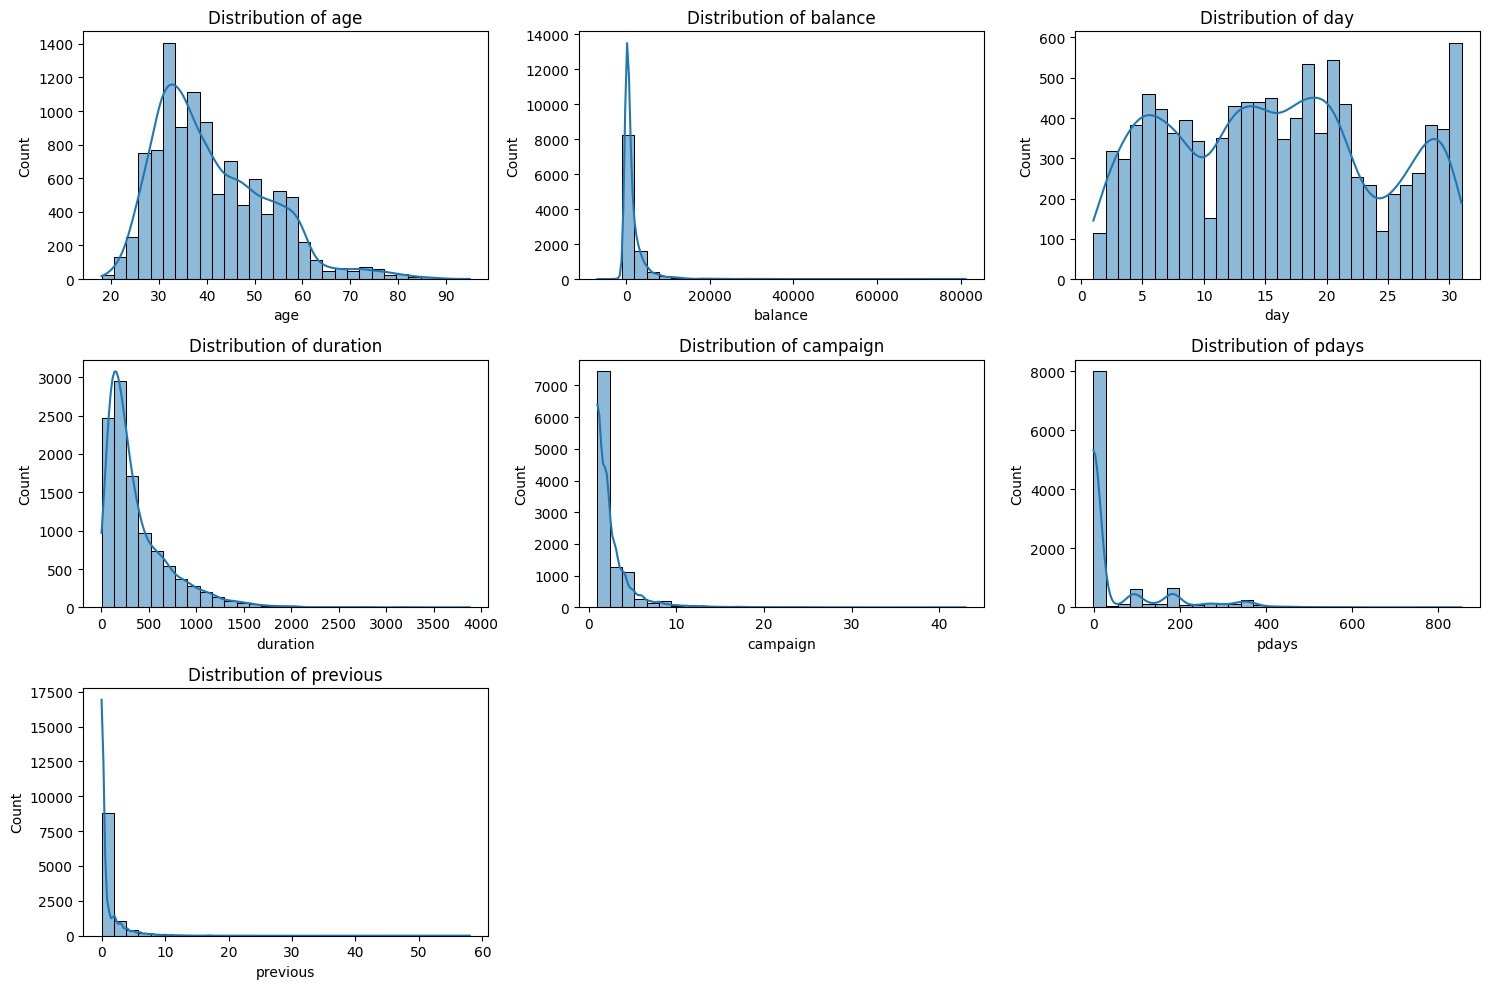

In [33]:
numeric_cols = [col for col in bank_data.columns if col not in categorical_cols]

plt.figure(figsize=(15,10))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(3, 3, i)
    sns.histplot(bank_data[col], bins=30, kde=True)
    plt.title(f"Distribution of {col}")

plt.tight_layout()
plt.show()


# Encoding

In [34]:
binary_cols = [col for col in categorical_cols if len(bank_data[col].unique())==2]
for col in binary_cols:
    if col == "contact":
        bank_data[col] = bank_data[col].map({'cellular': 1, 'telephone' : 0})
    else:
        bank_data[col] = bank_data[col].map({'yes': 1, 'no': 0})

In [35]:
non_binary_cols = [col for col in categorical_cols if col not in binary_cols]
encoders = {}

le = LabelEncoder()
for col in non_binary_cols:
    bank_data[col] = le.fit_transform(bank_data[col])
    encoders[col] = dict(zip(le.classes_, le.transform(le.classes_)))
    print(f"\nMapping for {col}:")
    print(encoders[col])


Mapping for job:
{'admin.': np.int64(0), 'blue-collar': np.int64(1), 'entrepreneur': np.int64(2), 'housemaid': np.int64(3), 'management': np.int64(4), 'retired': np.int64(5), 'self-employed': np.int64(6), 'services': np.int64(7), 'student': np.int64(8), 'technician': np.int64(9), 'unemployed': np.int64(10)}

Mapping for marital:
{'divorced': np.int64(0), 'married': np.int64(1), 'single': np.int64(2)}

Mapping for education:
{'primary': np.int64(0), 'secondary': np.int64(1), 'tertiary': np.int64(2)}

Mapping for month:
{'apr': np.int64(0), 'aug': np.int64(1), 'dec': np.int64(2), 'feb': np.int64(3), 'jan': np.int64(4), 'jul': np.int64(5), 'jun': np.int64(6), 'mar': np.int64(7), 'may': np.int64(8), 'nov': np.int64(9), 'oct': np.int64(10), 'sep': np.int64(11)}

Mapping for poutcome:
{'failure': np.int64(0), 'other': np.int64(1), 'success': np.int64(2), 'unknown': np.int64(3)}


# Corrlation Matrix

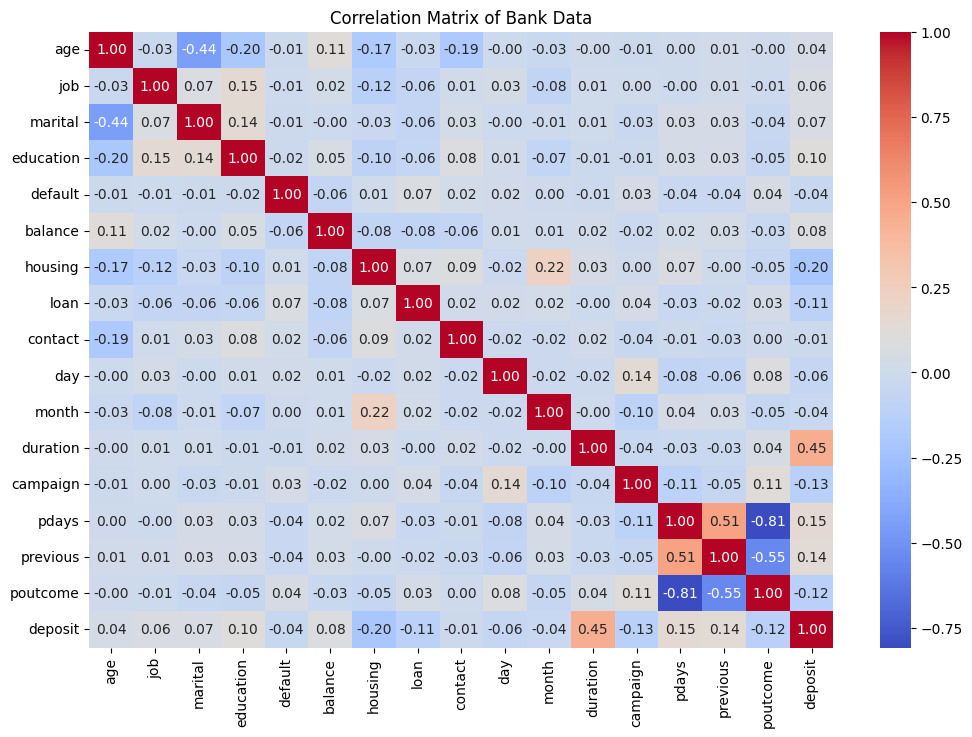

In [36]:
corr_matrix = bank_data.corr()

# Display the correlation matrix as a heatmap
plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Correlation Matrix of Bank Data")
plt.show()

| Relationship                    | Correlation | Interpretation                                                                                                                                           |
| ------------------------------- | ----------- | -------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **pdays ↔ previous**            | ≈ **+0.51** | If a person was contacted before, they also have fewer days since last contact — makes sense, but redundant info.                                        |
| **campaign ↔ poutcome**         | ≈ **−0.45** | More contacts (campaign) often correlate with an unsuccessful previous outcome — potential redundancy.                                                   |
| **duration ↔ deposit (target)** | ≈ **+0.45** | Long call duration strongly linked to term deposit success → very predictive, but note: **data leakage risk**, since duration is known *after* the call. |                    |
| **balance ↔ deposit**           | ≈ **−0.11** | Weak correlation; richer clients slightly less likely to deposit.                                                                                        |
| **housing ↔ deposit**           | ≈ **−0.20** | Clients with housing loans tend to say no to deposit.                                                                                                    |
| **loan ↔ deposit**              | ≈ **−0.11** | Clients with personal loans less likely to subscribe.                                                                                                    |


# Feature Engineering

In [37]:
# Droping Irrelevant Columns: day and duation
# duration-> It’s a strong predictor (0.45 correlation with deposit) but should not be used in model training — because it’s only known after the marketing call.

irrelevant_cols = ['duration']
bank_data = bank_data.drop(columns=irrelevant_cols)

In [38]:
# the correlation for this feature is -.93 wrt deposit, which is too high, hence chance of data leakage.

def contact_category(row):
    if row['pdays'] == -1:
        return 'Never contacted'
    elif row['pdays'] <= 5:
        return 'Recently contacted'
    elif row['previous'] > 2:
        return 'Frequently contacted'
    else:
        return 'Contacted long ago'

# bank_data['contact_status'] = bank_data.apply(contact_category, axis=1)
# bank_data['contact_status'] = le.fit_transform(bank_data['contact_status'])

In [39]:
#'pdays' → Number of days since the client was last contacted in a previous campaign. This is an important feature — frequent recent contacts may influence the outcome.
#'previous' → Number of times the client was contacted before this campaign. 0 → no previous contacts. Higher numbers mean the client was targeted multiple times.

# Since they are highly correlated, let's combine them and the drop the two, or choese one of them

bank_data['contacted_before'] = (bank_data['pdays'] != -1).astype(int)
bank_data.drop(['pdays', 'previous'], axis=1, inplace=True)
print(bank_data['contacted_before'].value_counts())

contacted_before
0    7939
1    2695
Name: count, dtype: int64


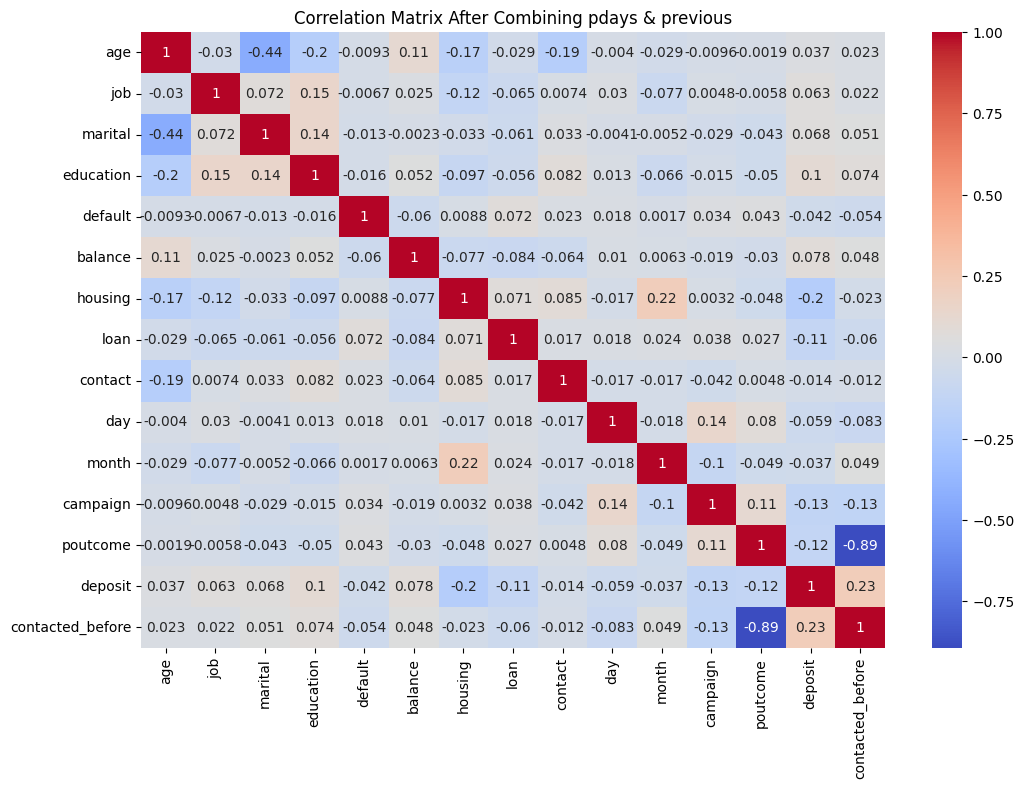

In [40]:
corr_matrix = bank_data.corr(numeric_only=True)
plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix After Combining pdays & previous")
plt.show()


# Training and Testing

## FAQ
* **Why we stratify in train_test_spit?**

    We stratify the data to ensure that the proportion of classes in the training and testing sets is the same as in the original dataset. This is crucial for building and evaluating a reliable machine learning model, especially when dealing with imbalanced datasets.

In [41]:
X = bank_data.drop('deposit', axis=1)
y = bank_data['deposit']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# What is a Decision Tree?
A Decision Tree is a flowchart-like structure that repeatedly splits your dataset based on feature values to predict a target.

Each split answers a simple question like:
```
“Is age > 40?”
“Does the client have a housing loan = yes?”
“Is balance < 500?”
```
The tree keeps splitting data into homogeneous groups (where most samples belong to the same class) until a stopping condition (like max_depth) is met.

# How it works (algorithmically)
The tree grows by maximizing information gain — it chooses the feature and threshold that best separates the target classes at each node.

The metric used can be:
- Gini impurity (default in scikit-learn)
- Entropy (information gain)
- Variance reduction (for regression trees)

At each node:
Compute impurity before the split.
Try splitting by each feature at every possible threshold.
Choose the split that yields the largest impurity reduction.
Repeat recursively for left and right branches.

# Why a Decision Tree for the Bank Marketing dataset?
| Reason                                  | Explanation                                                                                                                                        |
| --------------------------------------- | -------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Handles mixed data easily**       | The dataset has **categorical (job, marital, contact)** and **numerical (age, balance, duration)** columns. Trees can handle both without scaling. |
| **No need for feature scaling**     | Unlike logistic regression or SVMs, Decision Trees don’t need normalization or standardization.                                                    |
| **Naturally captures interactions** | E.g., `age > 40` *and* `loan = no` might be a strong indicator — trees handle such combinations automatically.                                     |
| **Interpretable rules**             | You can visualize the path that leads to a “yes” or “no” deposit — great for marketing explainability.                                             |
| **Non-linear decision boundaries**  | Many relationships (e.g., age vs deposit) are not linear — trees capture these easily.                                                             |
| **Fast to train, easy to tune**     | Perfect for an educational / exploratory project.                                                                                                  |


In **Bank Marketing model**, **Decision Trees** serve as:
“A powerful, explainable baseline model that captures patterns quickly before we move to more advanced ensembles (Random Forest, XGBoost).”

# Limitations (and how we handle them)
| Weakness                             | Effect                               | Mitigation                                       |
| ------------------------------------ | ------------------------------------ | ------------------------------------------------ |
| **Overfitting**                      | Tree memorizes training data         | Tune `max_depth`, `min_samples_leaf`             |
| **High variance**                    | Slight data change → different tree  | Use ensembles (Random Forest, Gradient Boosting) |
| **Not great with unseen categories** | If new category appears in test data | Use encoding with `handle_unknown='ignore'`      |
| **No probabilistic calibration**     | Output is deterministic              | Later, calibrate or use ensemble models          |


# Cross Validation to check best Parameters for Decision Tree

## Why Cross Validation?
When you manually set hyperparameters (max_depth, min_samples_leaf, etc.), you risk:
- Underfitting → tree too shallow, misses patterns
- Overfitting → tree too deep, memorizes noise

Cross-validation helps you objectively evaluate multiple parameter combinations on different splits of your training data to find what generalizes best — before you ever touch the test set.

## How Cross-Validation Works?
Instead of training on one train/test split:
- The training data is split into K folds (usually 5 or 10).
- The model trains on K-1 folds and validates on the remaining one.
- This repeats K times so every fold serves as validation once.
- The performance metrics (accuracy, F1, etc.) are **averaged**.

This ensures the model’s performance is not dependent on a single random split.

## Techniques We Can Use?
| Technique              | What it does                                        | When to use                                        | Pros                                   |
| ---------------------- | --------------------------------------------------- | -------------------------------------------------- | -------------------------------------- |
| **GridSearchCV**       | Tries all combinations of specified hyperparameters | When parameter space is small (e.g. Decision Tree) | Systematic, easy to interpret          |
| **RandomizedSearchCV** | Tries random combinations from parameter ranges     | When parameter space is large                      | Faster, good for tuning complex models |
| **StratifiedKFold**    | Ensures each fold has same class proportion         | For imbalanced target (like `deposit`)             | Keeps folds representative             |
| **cross_val_score**    | Simple cross-validation evaluation                  | For quick scoring without tuning                   | Lightweight                            |

For this project I will be using **GridSearchCV** with **Stratified K-Fold cross-validation**:
- The parameter grid for Decision Tree is small.
- We have a classification problem with mild class imbalance (yes/no deposit).
- We want to be certain about interpretability and stability.

In [42]:
print(bank_data['deposit'].value_counts())

len(bank_data['deposit'])

no_ratio = (bank_data['deposit'] == 0).mean()
print(f"Proportion of deposit=0 clients: {no_ratio:.2f}")


deposit
0    5613
1    5021
Name: count, dtype: int64
Proportion of deposit=0 clients: 0.53


# Why “f1_macro” scoring?
Our target (deposit) is imbalanced (typically around 88–90% “no” and 10–12% “yes”). though in our case we have 53% no and 47% yes, in general it is hif=ghly impalances sityation.
If you only optimize accuracy, the model can predict “no” for everything and still be 90% correct.
f1_macro (or balanced_accuracy) treats both classes equally important.

In [43]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV,StratifiedKFold 
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

model = DecisionTreeClassifier(random_state=42)

# 
param_grid ={
    'criterion': ['gini', 'entropy'],
    'max_depth': [3,5,7,9,None],
    'min_samples_split': [2,5,10,20], #Mininum number of samples required to be in the node to be considered for spliting
    'min_samples_leaf': [1,5,10,20], #minimum number of samples required to be at a leaf node after the split.
}

cv = StratifiedKFold(n_splits=5,shuffle=True, random_state=42)

'''
verbose: you can set it to 1 to get the detailed print out while you fit the data to GridSearchCV
n_jobs: number of processes you wish to run in parallel for this task if it -1 it will use all available processors.
'''
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=cv,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 160 candidates, totalling 800 fits


[CV] END criterion=gini, max_depth=3, min_samples_leaf=1, min_samples_split=2; total time=   0.0s
[CV] END criterion=gini, max_depth=3, min_samples_leaf=1, min_samples_split=2; total time=   0.0s
[CV] END criterion=gini, max_depth=3, min_samples_leaf=1, min_samples_split=2; total time=   0.0s
[CV] END criterion=gini, max_depth=3, min_samples_leaf=1, min_samples_split=2; total time=   0.0s
[CV] END criterion=gini, max_depth=3, min_samples_leaf=1, min_samples_split=2; total time=   0.0s
[CV] END criterion=gini, max_depth=3, min_samples_leaf=1, min_samples_split=5; total time=   0.0s
[CV] END criterion=gini, max_depth=3, min_samples_leaf=1, min_samples_split=5; total time=   0.0s
[CV] END criterion=gini, max_depth=3, min_samples_leaf=1, min_samples_split=5; total time=   0.0s
[CV] END criterion=gini, max_depth=3, min_samples_leaf=1, min_samples_split=5; total time=   0.0s
[CV] END criterion=gini, max_depth=3, min_samples_leaf=1, min_samples_split=5; total time=   0.0s
[CV] END criterion=g

,estimator,DecisionTreeC...ndom_state=42)
,param_grid,"{'criterion': ['gini', 'entropy'], 'max_depth': [3, 5, ...], 'min_samples_leaf': [1, 5, ...], 'min_samples_split': [2, 5, ...]}"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'entropy'


In [44]:
print(f"Best Parameters:\n {grid_search.best_params_}")
print(f"Best CV Score: \n {grid_search.best_score_}")

# Evaluation on Test Set
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

print(f"\nTest Accuracy: \n{accuracy_score(y_test, y_pred)}")
print(f"\nClassification Report: \n {classification_report(y_test,y_pred)}")

Best Parameters:
 {'criterion': 'entropy', 'max_depth': 9, 'min_samples_leaf': 20, 'min_samples_split': 2}
Best CV Score: 
 0.6779858127054016

Test Accuracy: 
0.6831217677480019

Classification Report: 
               precision    recall  f1-score   support

           0       0.67      0.78      0.72      1123
           1       0.70      0.58      0.63      1004

    accuracy                           0.68      2127
   macro avg       0.69      0.68      0.68      2127
weighted avg       0.69      0.68      0.68      2127



# Since out target value is balanced

In [45]:
model = DecisionTreeClassifier(class_weight='balanced', random_state=42)

param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [6, 7, 8, 9],
    'min_samples_split': [5, 10, 15],
    'min_samples_leaf': [5, 10, 15],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=cv,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 72 candidates, totalling 360 fits
[CV] END criterion=gini, max_depth=6, min_samples_leaf=5, min_samples_split=5; total time=   0.0s
[CV] END criterion=gini, max_depth=6, min_samples_leaf=5, min_samples_split=5; total time=   0.0s
[CV] END criterion=gini, max_depth=6, min_samples_leaf=5, min_samples_split=5; total time=   0.0s
[CV] END criterion=gini, max_depth=6, min_samples_leaf=5, min_samples_split=5; total time=   0.1s
[CV] END criterion=gini, max_depth=6, min_samples_leaf=5, min_samples_split=5; total time=   0.0s
[CV] END criterion=gini, max_depth=6, min_samples_leaf=5, min_samples_split=10; total time=   0.0s
[CV] END criterion=gini, max_depth=6, min_samples_leaf=5, min_samples_split=10; total time=   0.0s
[CV] END criterion=gini, max_depth=6, min_samples_leaf=5, min_samples_split=10; total time=   0.0s
[CV] END criterion=gini, max_depth=6, min_samples_leaf=5, min_samples_split=10; total time=   0.0s
[CV] END criterion=gini, max_depth=6, min_samples_le

,estimator,DecisionTreeC...ndom_state=42)
,param_grid,"{'criterion': ['gini', 'entropy'], 'max_depth': [6, 7, ...], 'min_samples_leaf': [5, 10, ...], 'min_samples_split': [5, 10, ...]}"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


In [46]:
print("Best Parameters:\n", grid_search.best_params_)
print("Best CV Score:\n", grid_search.best_score_)

best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Best Parameters:
 {'criterion': 'gini', 'max_depth': 9, 'min_samples_leaf': 10, 'min_samples_split': 5}
Best CV Score:
 0.677838668401897
Test Accuracy: 0.688293370944993
Classification Report:
               precision    recall  f1-score   support

           0       0.69      0.75      0.72      1123
           1       0.69      0.62      0.65      1004

    accuracy                           0.69      2127
   macro avg       0.69      0.68      0.68      2127
weighted avg       0.69      0.69      0.69      2127



# What is Pruning or cost complexity tuning

## What is Pruning?
A Decision Tree grows by splitting data recursively —
each split tries to reduce **impurity (like Gini or Entropy)**.
If you let it grow freely, it keeps splitting until:
- all leaves are pure (contain only one class), or
- each leaf has just one data point.

**Result:** Overfitting —
the tree memorizes the training data and performs poorly on unseen data.

**Pruning** is the process of cutting back the overgrown parts of the tree to prevent overfitting.
Think of a Decision Tree like a student learning from examples:
- Without pruning, the student memorizes every training question (overfit).
- With pruning, the student keeps only general patterns that apply to new situations.

## Types of Pruning
| Type                                       | Description                                                                                             | When Applied              |
| ------------------------------------------ | ------------------------------------------------------------------------------------------------------- | ------------------------- |
| **Pre-pruning (Early stopping)**           | You stop growing the tree early — by setting `max_depth`, `min_samples_split`, `min_samples_leaf`, etc. | During tree growth        |
| **Post-pruning (Cost complexity pruning)** | You first grow the full tree, then remove unnecessary branches using a cost function.                   | After tree is fully grown |

we are ussing **post-pruning** — a.k.a. Cost Complexity Pruning (CCP):

## What is Cost Complexity Pruning (CCP)?
It’s a formal way to find the “sweet spot” between:
- Tree accuracy (fit to data) and
- Tree simplicity (fewer splits)
It adds a penalty for each extra branch (complexity) in the tree.
For every possible subtree $T$, define the Cost Complexity:
$R_{\alpha}(T) = R(T) + \alpha \cdot |T|$
| Symbol     | Meaning                                           |   |                                 |
| ---------- | ------------------------------------------------- | - | ------------------------------- |
| ( R(T) )   | Misclassification error (or impurity) of the tree |   |                                 |
| ( $\alpha$ ) | Complexity parameter (pruning penalty)            |   |                                 |

- $\alpha$=0: no penalty → the tree grows fully (overfitted).
- As $\alpha$ increases → we penalize complexity → prune more branches.
- Too high $\alpha$: tree becomes too small (underfit).
The goal is to find the optimal α that gives the lowest validation error.

In [47]:
# get pruning path from a fresh estimator
tmp_dt = DecisionTreeClassifier(random_state=42)
path = tmp_dt.cost_complexity_pruning_path(X_train, y_train)
alphas = path.ccp_alphas

selected_alphas = np.unique(np.linspace(alphas.min(), alphas.max(), 6))

# add ccp_alpha to param grid (extend existing param_grid)
param_grid_with_pruning = param_grid.copy()
param_grid_with_pruning['ccp_alpha'] = selected_alphas

grid_search_pruned = GridSearchCV(
    estimator=DecisionTreeClassifier(class_weight='balanced', random_state=42),
    param_grid=param_grid_with_pruning,
    cv=cv,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=2
)
grid_search_pruned.fit(X_train, y_train)

Fitting 5 folds for each of 432 candidates, totalling 2160 fits
[CV] END ccp_alpha=0.0, criterion=gini, max_depth=6, min_samples_leaf=5, min_samples_split=5; total time=   0.0s
[CV] END ccp_alpha=0.0, criterion=gini, max_depth=6, min_samples_leaf=5, min_samples_split=5; total time=   0.0s
[CV] END ccp_alpha=0.0, criterion=gini, max_depth=6, min_samples_leaf=5, min_samples_split=5; total time=   0.1s
[CV] END ccp_alpha=0.0, criterion=gini, max_depth=6, min_samples_leaf=5, min_samples_split=5; total time=   0.1s
[CV] END ccp_alpha=0.0, criterion=gini, max_depth=6, min_samples_leaf=5, min_samples_split=5; total time=   0.1s
[CV] END ccp_alpha=0.0, criterion=gini, max_depth=6, min_samples_leaf=5, min_samples_split=10; total time=   0.0s
[CV] END ccp_alpha=0.0, criterion=gini, max_depth=6, min_samples_leaf=5, min_samples_split=10; total time=   0.0s
[CV] END ccp_alpha=0.0, criterion=gini, max_depth=6, min_samples_leaf=5, min_samples_split=10; total time=   0.1s
[CV] END ccp_alpha=0.0, crite

[CV] END ccp_alpha=0.0, criterion=entropy, max_depth=7, min_samples_leaf=10, min_samples_split=5; total time=   0.0s
[CV] END ccp_alpha=0.0, criterion=entropy, max_depth=7, min_samples_leaf=10, min_samples_split=10; total time=   0.1s
[CV] END ccp_alpha=0.0, criterion=entropy, max_depth=7, min_samples_leaf=10, min_samples_split=5; total time=   0.0s
[CV] END ccp_alpha=0.0, criterion=entropy, max_depth=7, min_samples_leaf=10, min_samples_split=10; total time=   0.1s
[CV] END ccp_alpha=0.0, criterion=entropy, max_depth=7, min_samples_leaf=10, min_samples_split=10; total time=   0.0s
[CV] END ccp_alpha=0.0, criterion=entropy, max_depth=7, min_samples_leaf=10, min_samples_split=10; total time=   0.0s
[CV] END ccp_alpha=0.0, criterion=entropy, max_depth=7, min_samples_leaf=10, min_samples_split=10; total time=   0.1s
[CV] END ccp_alpha=0.0, criterion=entropy, max_depth=7, min_samples_leaf=10, min_samples_split=15; total time=   0.1s
[CV] END ccp_alpha=0.0, criterion=entropy, max_depth=7, mi

,estimator,DecisionTreeC...ndom_state=42)
,param_grid,"{'ccp_alpha': array([0. ... 0.02593308]), 'criterion': ['gini', 'entropy'], 'max_depth': [6, 7, ...], 'min_samples_leaf': [5, 10, ...], ...}"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


In [48]:
print("\n Best Params (with pruning):", grid_search_pruned.best_params_)
print("\n Best CV Score (with pruning):", grid_search_pruned.best_score_)

best_pruned = grid_search_pruned.best_estimator_
y_pred_pruned = best_pruned.predict(X_test)
print("\n Test report (pruned):\n", classification_report(y_test, y_pred_pruned))


 Best Params (with pruning): {'ccp_alpha': np.float64(0.0), 'criterion': 'gini', 'max_depth': 9, 'min_samples_leaf': 10, 'min_samples_split': 5}

 Best CV Score (with pruning): 0.677838668401897

 Test report (pruned):
               precision    recall  f1-score   support

           0       0.69      0.75      0.72      1123
           1       0.69      0.62      0.65      1004

    accuracy                           0.69      2127
   macro avg       0.69      0.68      0.68      2127
weighted avg       0.69      0.69      0.69      2127



In [49]:
print("\n Best Params (with pruning):", grid_search_pruned.best_params_)
print("\n Best CV Score (with pruning):", grid_search_pruned.best_score_)

best_pruned = grid_search_pruned.best_estimator_
y_pred_pruned = best_pruned.predict(X_test)
print("\n Test report (pruned):\n", classification_report(y_test, y_pred_pruned))


 Best Params (with pruning): {'ccp_alpha': np.float64(0.0), 'criterion': 'gini', 'max_depth': 9, 'min_samples_leaf': 10, 'min_samples_split': 5}

 Best CV Score (with pruning): 0.677838668401897

 Test report (pruned):
               precision    recall  f1-score   support

           0       0.69      0.75      0.72      1123
           1       0.69      0.62      0.65      1004

    accuracy                           0.69      2127
   macro avg       0.69      0.68      0.68      2127
weighted avg       0.69      0.69      0.69      2127



# Why move to ensembles now
| Reason                              | Explanation                                                                                        |
| ----------------------------------- | -------------------------------------------------------------------------------------------------- |
| **Variance reduction**              | Ensembles average multiple trees, so small data perturbations don’t change results drastically.    |
| **Higher recall on minority class** | Boosting methods (like XGBoost/LightGBM) directly optimize classification errors for harder cases. |
| **F1 macro boost**                  | Expect your macro F1 to rise from ~0.68 → **0.75–0.80** range.                                     |
| **Better generalization**           | Ensemble trees use bagging/boosting to smooth decision boundaries.                                 |


# Recommended next step
| Model                               | Why                                                                                   |
| ----------------------------------- | ------------------------------------------------------------------------------------- |
| **RandomForestClassifier**          | Simple bagging approach, low overfitting risk, great for feature importance           |
| **XGBoost / LightGBM / CatBoost**   | Boosting approach — builds trees sequentially to fix previous mistakes, more accurate |
| **Evaluate on F1-macro, recall(1)** | Because you care more about identifying “Yes” deposits                                |


# Dumping the Pickle File

In [ ]:
best_model = grid_search_pruned.best_estimator_

with open("/workspaces/Machine-Learning-for-Bank-Marketing/models/decision_tree_pruned_model.pkl", "wb") as f:
    pickle.dump(best_model, f)

print("Saved best Decision Tree model as decision_tree_pruned_model.pkl")

Saved best Decision Tree model as decision_tree_pruned_model.pkl
